<a href="https://colab.research.google.com/github/Reva694/rawuh-model/blob/main/BRAIN_TUMOR_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TUGAS CNN
REVA SEBRINA SALSABILA | 5231911013
Dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

In [ ]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# MELIHAT STRUKTUR DATA DALAM FOLDER
for root, dirs, files in os.walk(path):
    print(root)
    print("Jumlah file:", len(files))
    print("-"*50)

/kaggle/input/brain-tumor-mri-dataset
Jumlah file: 0
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Training
Jumlah file: 0
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Jumlah file: 1400
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Training/notumor
Jumlah file: 1400
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma
Jumlah file: 1400
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Training/glioma
Jumlah file: 1400
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Testing
Jumlah file: 0
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary
Jumlah file: 400
--------------------------------------------------
/kaggle/input/brain-tumor-mri-dataset/Testing/n

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Cek GPU
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow versi : {tf.__version__}')
print(f'GPU tersedia     : {[g.name for g in gpus] if gpus else "Tidak ada – aktifkan GPU di Runtime!"}')

TensorFlow versi : 2.20.0
GPU tersedia     : ['/physical_device:GPU:0']


In [ ]:
import os # Tambahkan baris ini
import kagglehub # Tambahkan baris ini
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset") # Tambahkan baris ini

 # ── Hyperparameter ────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 1e-3
NUM_CLASSES   = 4
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

train_dir = os.path.join(path, 'Training')
test_dir  = os.path.join(path, 'Testing')

print(' Konfigurasi siap')
print(f'   Image size  : {IMG_SIZE}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Epochs      : {EPOCHS}')
print(f'   Kelas       : {CLASS_NAMES}')

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
 Konfigurasi siap
   Image size  : (224, 224)
   Batch size  : 32
   Epochs      : 20
   Kelas       : ['glioma', 'meningioma', 'notumor', 'pituitary']


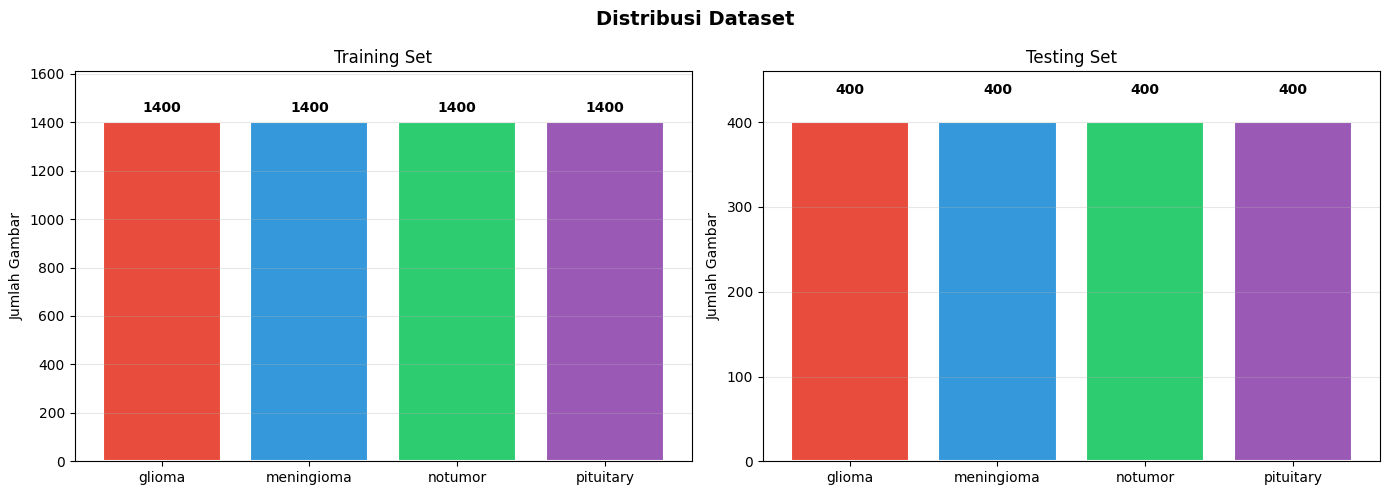

In [ ]:
# ── Distribusi kelas ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset', fontsize=14, fontweight='bold')

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for ax, split, title in zip(axes, ['Training', 'Testing'], ['Training Set', 'Testing Set']):
    split_path = os.path.join(path, split)
    counts = {}
    for cls in CLASS_NAMES:
        p = os.path.join(split_path, cls)
        counts[cls] = len(os.listdir(p)) if os.path.exists(p) else 0

    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Jumlah Gambar')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts.values()) * 1.15)

plt.tight_layout()
plt.show()

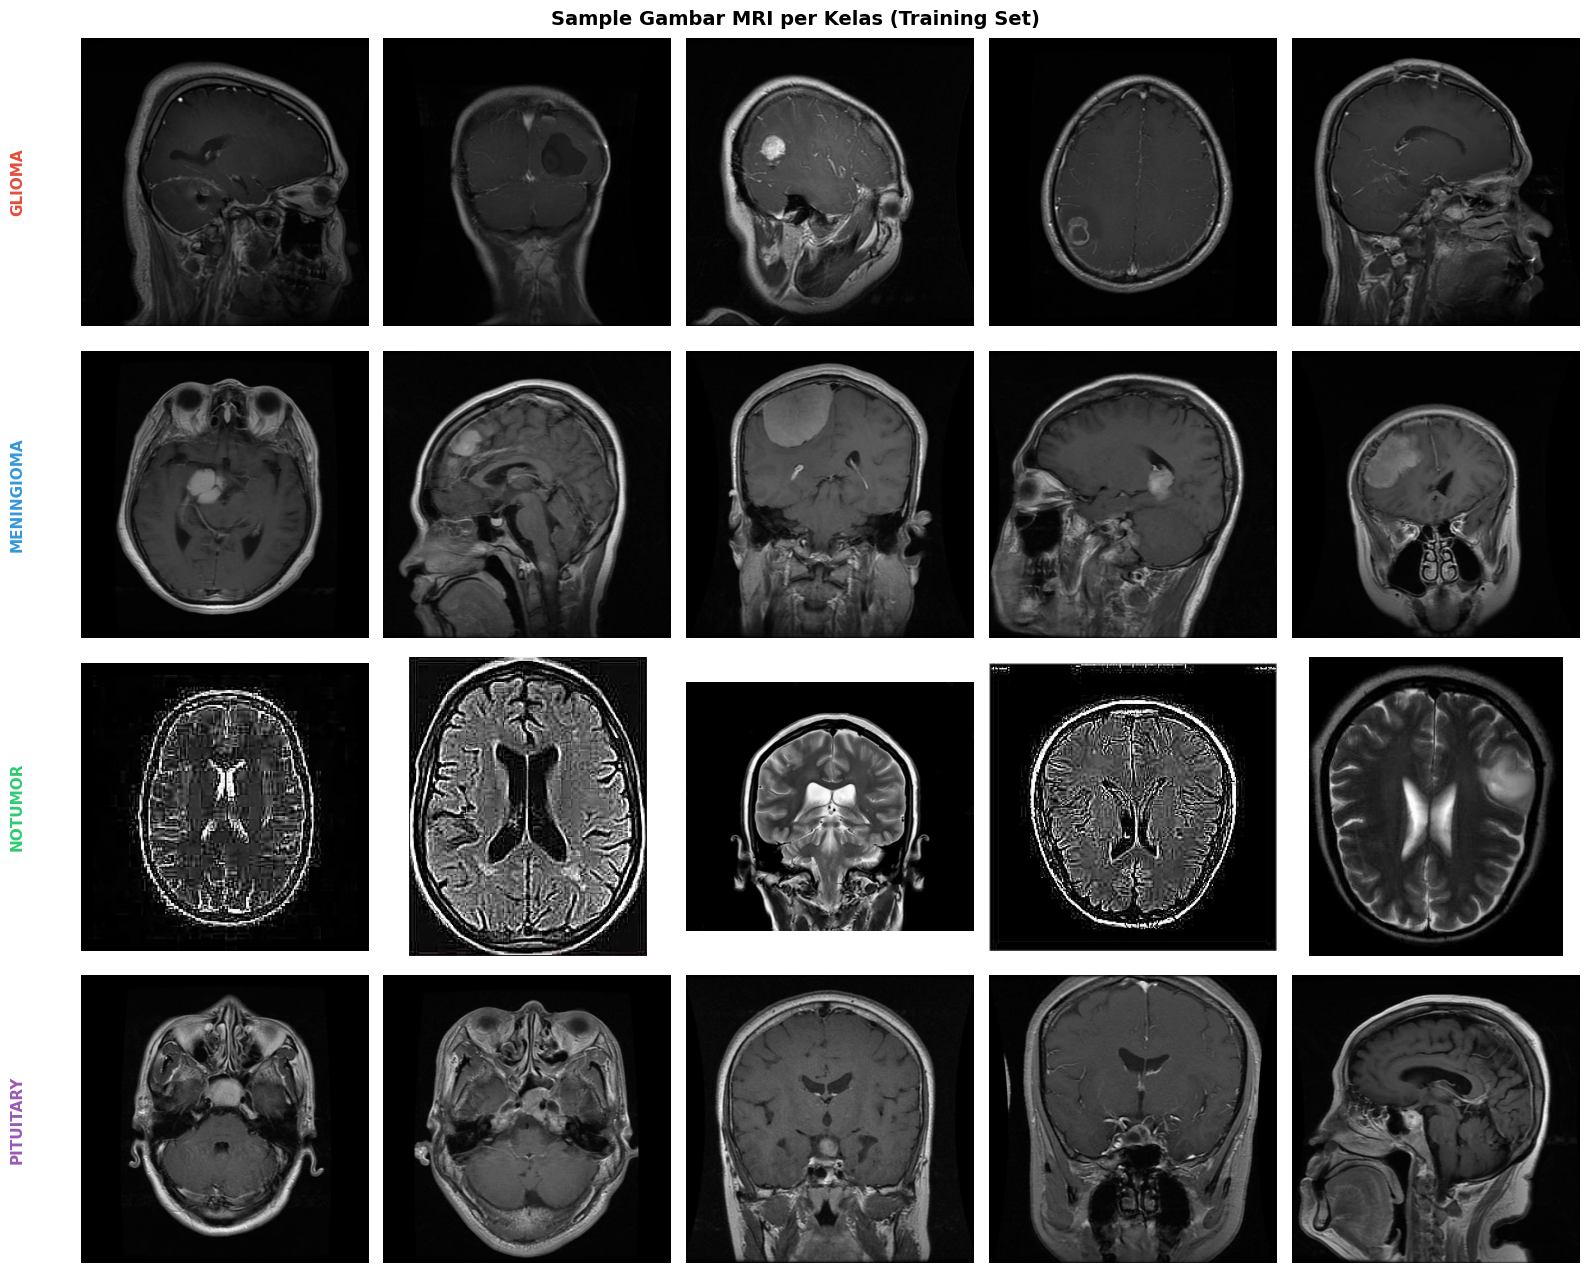

In [ ]:
# ── Tampilkan sample gambar per kelas ─────────────────────────────────
from PIL import Image

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Sample Gambar MRI per Kelas (Training Set)', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(train_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))][:5]
    for col, fname in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.upper(), fontsize=11, fontweight='bold',
                                      color=colors[row], rotation=90, labelpad=40)
            axes[row][col].axis('on')
            axes[row][col].set_xticks([])
            axes[row][col].set_yticks([])
            for spine in axes[row][col].spines.values():
                spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ── Buat data generator dengan augmentasi ────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15,
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED)

val_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f'\n Generator siap')
print(f'   Training  : {train_gen.samples} gambar')
print(f'   Validasi  : {val_gen.samples} gambar')
print(f'   Test      : {test_gen.samples} gambar')

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

 Generator siap
   Training  : 4760 gambar
   Validasi  : 840 gambar
   Test      : 1600 gambar


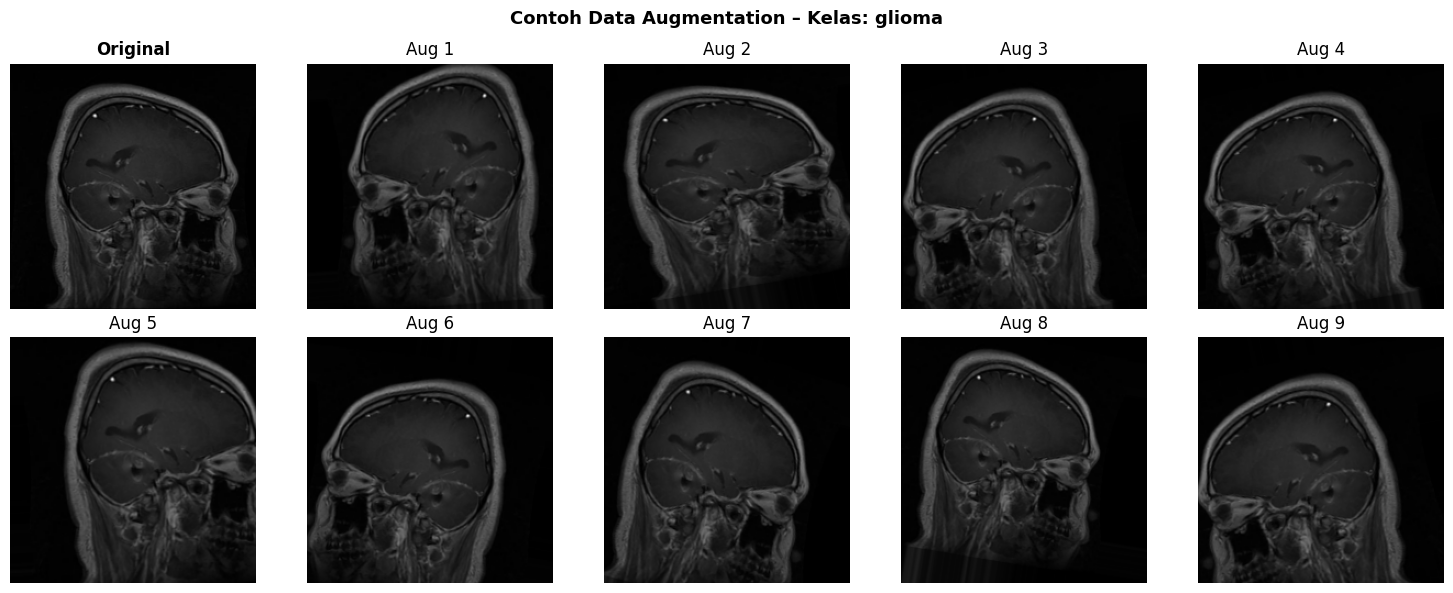

In [ ]:
# ── Visualisasi hasil augmentasi ─────────────────────────────────────
aug_only = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')

cls_sample = 'glioma'
sample_path = os.path.join(train_dir, cls_sample)
orig_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0])).convert('RGB').resize(IMG_SIZE)
orig_arr = np.array(orig_img).reshape(1, *IMG_SIZE, 3)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Contoh Data Augmentation – Kelas: {cls_sample}', fontsize=13, fontweight='bold')
axes[0][0].imshow(orig_img); axes[0][0].set_title('Original', fontweight='bold'); axes[0][0].axis('off')

aug_gen = aug_only.flow(orig_arr, batch_size=1)
positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for (r,c) in positions:
    aug_img = next(aug_gen)[0].astype('uint8')
    axes[r][c].imshow(aug_img); axes[r][c].set_title(f'Aug {r*5+c}'); axes[r][c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense # Tambahkan baris ini

# MEMBUAT MODEL
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'NUM_CLASSES' is not defined

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.ModelCheckpoint('/content/best_cnn.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1),
]

# TRAIN DATA
print('🚀 Training dimulai...')
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cb,
)

🚀 Training dimulai...
Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.4453 - loss: 1.3933
Epoch 1: val_accuracy improved from None to 0.65357, saving model to /content/best_cnn.keras

Epoch 1: finished saving model to /content/best_cnn.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 102s 638ms/step - accuracy: 0.5599 - loss: 1.0228 - val_accuracy: 0.6536 - val_loss: 0.7963 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7268 - loss: 0.6992
Epoch 2: val_accuracy improved from 0.65357 to 0.71548, saving model to /content/best_cnn.keras

Epoch 2: finished saving model to /content/best_cnn.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 482ms/step - accuracy: 0.7342 - loss: 0.6825 - val_accuracy: 0.7155 - val_loss: 0.7036 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7523 - loss: 0.6271
Epoch 3: val_accuracy improved from 0.71548 to 0.73690, saving model to /content/best_cnn.keras

Epoch 3: finished sav

In [ ]:
loss, accuracy = model.evaluate(test_gen)

print("Loss :", loss)
print("Accuracy :", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.8369 - loss: 1.0828
Loss : 1.0827603340148926
Accuracy : 0.8368750214576721


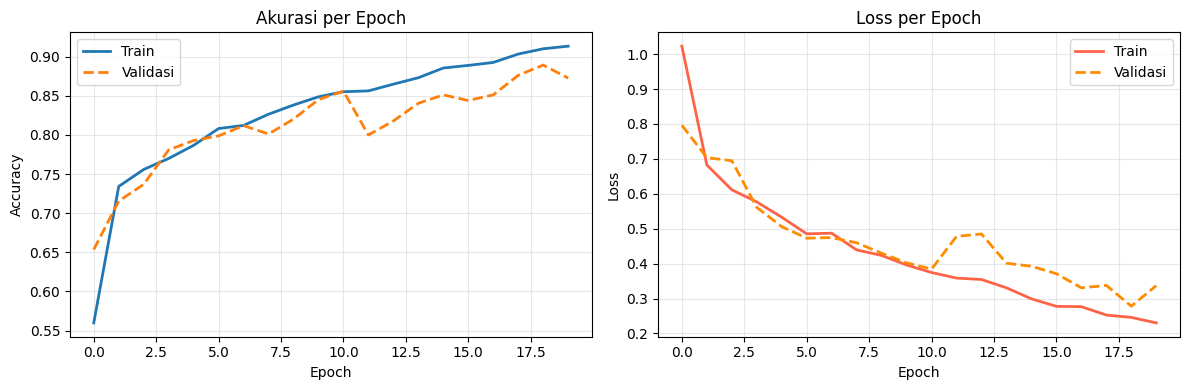

In [ ]:
# ── Plot training history ─────────────────────────────────────────────
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], '--', label='Validasi', linewidth=2)
plt.title('Akurasi per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='tomato', label='Train', linewidth=2)
plt.plot(history.history['val_loss'], '--', color='darkorange', label='Validasi', linewidth=2)
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Prediksi ─────────────────────────────────────────────────────────
test_gen.reset()
y_pred_prob = model.predict(test_gen)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step


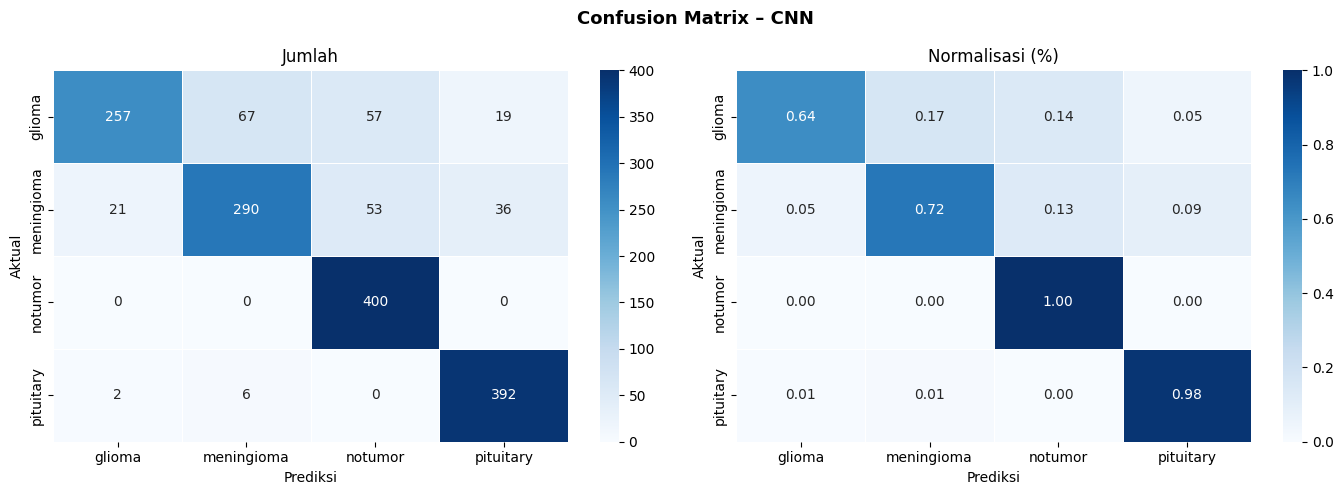

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix – CNN', fontsize=13, fontweight='bold')

for ax, data, fmt, t in zip(axes, [cm, cm_norm], ['d', '.2f'],
                            ['Jumlah', 'Normalisasi (%)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=0.5, cbar=True)
    ax.set_title(t)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [ ]:
# ── Classification Report ─────────────────────────────────────────────
from sklearn.metrics import classification_report

print('\n Classification Report:')
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)


 Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.64      0.76       400
  meningioma       0.80      0.72      0.76       400
     notumor       0.78      1.00      0.88       400
   pituitary       0.88      0.98      0.93       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.83      1600
weighted avg       0.84      0.84      0.83      1600



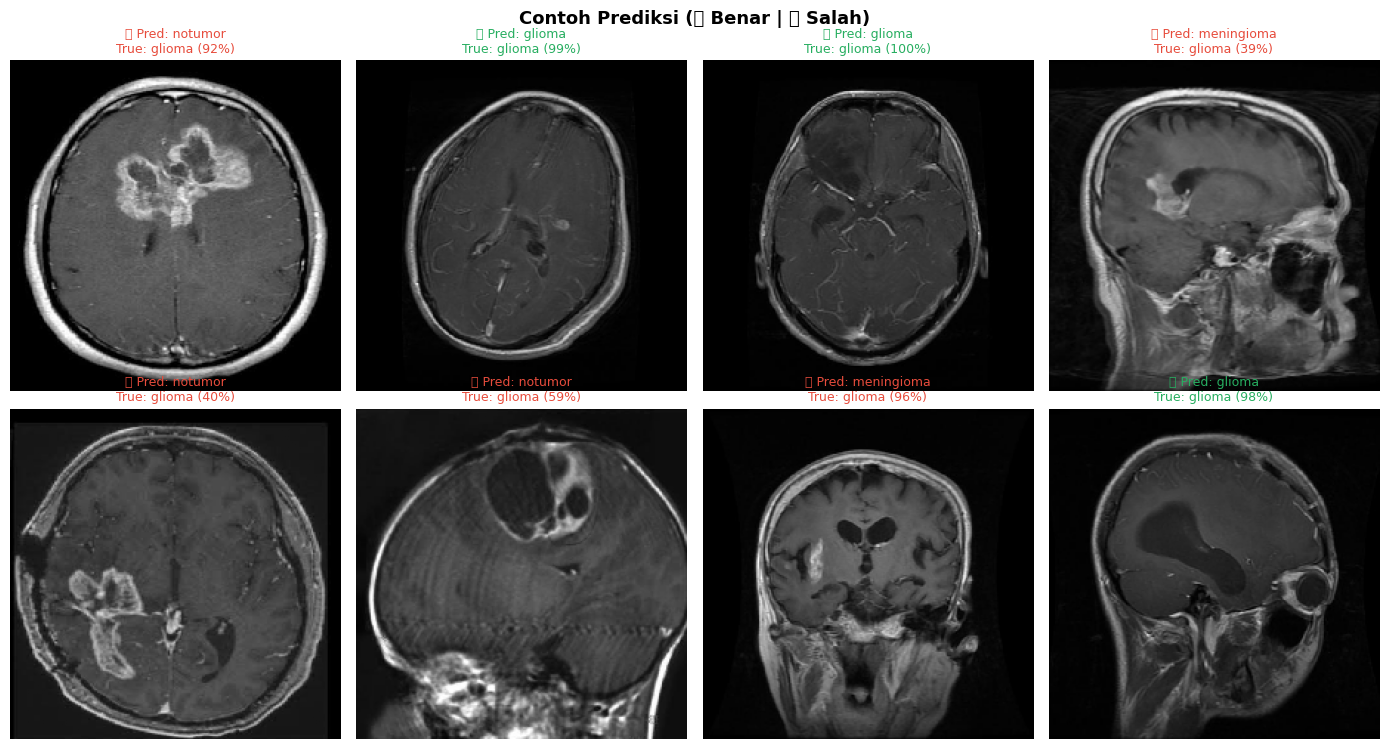

In [ ]:
# ── Visualisasi prediksi gambar ───────────────────────────────────────
def show_predictions(model, generator, class_names, n=8):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images[:n], verbose=0)
    pred_cls = np.argmax(preds, axis=1)
    true_cls = np.argmax(labels[:n], axis=1)

    cols = 4; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3.8))
    axes = axes.flatten()
    fig.suptitle('Contoh Prediksi (✅ Benar | ❌ Salah)', fontsize=13, fontweight='bold')

    for i in range(n):
        axes[i].imshow(images[i])
        correct = pred_cls[i] == true_cls[i]
        conf = preds[i][pred_cls[i]] * 100
        emoji = '✅' if correct else '❌'
        color = '#27AE60' if correct else '#E74C3C'
        axes[i].set_title(
            f'{emoji} Pred: {class_names[pred_cls[i]]}\nTrue: {class_names[true_cls[i]]} ({conf:.0f}%)',
            color=color, fontsize=9)
        axes[i].axis('off')

    for j in range(n, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(model, test_gen, CLASS_NAMES)